# Full Integrated Analysis: Performance & Environmental Impact
This notebook combines visualization modules and executes them using data from `../../experimental_data`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import re
import os
import math
import io
from pathlib import Path
from scipy import stats
from math import pi
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

# --- Global Settings ---
plt.rcParams.update({
    'font.size': 14, 'axes.labelsize': 16, 'pdf.fonttype': 42, 
    'ps.fonttype': 42, 'font.family': 'sans-serif'
})
sns.set_theme(style="whitegrid")

DATA_PATH = Path("../../experiments_data")
OUT_DIR = "../outputs"
REPOS = ["Sim_Grouille", "Sim_Grouille_matrix", "Sim_Chuc", "Sim_Chuc_matrix", "Sim_Hydra", "Sim_Hydra_matrix"]
DISPLAY_NAME = {
    "Sim_Grouille": "2×A100 - Addition", "Sim_Grouille_matrix": "2×A100 - MatMul",
    "Sim_Chuc": "4×A100 - Addition", "Sim_Chuc_matrix": "4×A100 - MatMul",
    "Sim_Hydra": "H100 - Addition", "Sim_Hydra_matrix": "H100 - MatMul"
}
SCALE_MAP = {"GWP": 1000.0, "ADPe": 1e6, "WU": 1000.0}
UNIT_LABELS = {"GWP": "g CO2 eq", "ADPe": "mg Sb eq", "WU": "L"}

INFRAS = ["2×A100", "4×A100", "H100"]
TASKS = ["Addition", "MatMul"]

csv_success = """Model,Average Addition (%),Average MatMul (%)
gemma3:12b,58.6,17.6
qwen3:14b,37.6,41.5
gemma3:27b,41.7,33.5
qwen3:30b,50.8,49.3"""

STREAMING_DATA = """Resolution,factor,value/hour
720,GWP,4.14e-02
720,WU,2.22e-01
720,ADPe,6.52e-06"""

df_sr = pd.read_csv(io.StringIO(csv_success))

In [2]:
def load_global_impacts_from_repos(root: Path, repos):
    rows = []
    for repo in repos:
        repo_path = root / repo
        if not repo_path.exists():
            continue
        found = find_data_files(repo_path)
        p = found.get("global_impacts")
        if not p:
            continue
        try:
            df = pd.read_csv(p)
        except Exception:
            continue

        # If the CSV contains per-GPU rows plus aggregated GLOBAL rows, prefer
        # the aggregated/global rows (gpu == 'GLOBAL' or scope == 'global').
        try:
            if "gpu" in df.columns and df["gpu"].astype(str).str.upper().isin(["GLOBAL"]).any():
                df = df[df["gpu"].astype(str).str.upper() == "GLOBAL"].copy()
            elif "scope" in df.columns and df["scope"].astype(str).str.lower().isin(["global"]).any():
                df = df[df["scope"].astype(str).str.lower() == "global"].copy()
        except Exception:
            # be forgiving and continue with original df on any error
            pass

        # try to find factor and value columns
        if "factor" not in df.columns:
            # if common factor columns present, melt them
            possible_factors = [c for c in ("GWP", "ADPe", "WU") if c in df.columns]
            if possible_factors:
                m = df.melt(value_vars=possible_factors, var_name="factor", value_name="value")
                # preserve model/nb_users if present
                for c in ("model", "nb_user"):
                    if c in df.columns:
                        m[c] = df[c].repeat(len(possible_factors)).values
                df = m

        # determine value column
        value_col = None
        for c in ("total", "value", "impact"):
            if c in df.columns:
                value_col = c
                break
        if value_col is None:
            numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
            numeric_cols = [c for c in numeric_cols if c not in ("nb_user", "mean_success_percent")]
            if numeric_cols:
                value_col = numeric_cols[0]
        if value_col is None:
            continue

        for _, r in df.iterrows():
            rows.append({
                "repo": repo,
                "factor": r.get("factor", ""),
                "model": r.get("model", "unknown"),
                "nb_users": int(r.get("nb_user", 1)) if not pd.isna(r.get("nb_user", 1)) else 1,
                "value": float(r.get(value_col, 0.0) or 0.0),
            })

    if not rows:
        return pd.DataFrame(columns=["repo", "factor", "model", "nb_users", "value"])
    return pd.DataFrame(rows)

In [3]:
def load_latencies_from_repos(root: Path, repos):
    rows = []
    for repo in repos:
        repo_path = root / repo
        if not repo_path.exists():
            continue
        found = find_data_files(repo_path)
        for p in found.get("raw_latencies", []):
            try:
                df = pd.read_csv(p)
            except Exception:
                continue
            fname = p.name
            model = fname.replace("raw_latencies_", "").replace(".csv", "") if fname.startswith("raw_latencies_") else None
            if "latency" in df.columns:
                latcol = "latency"
            else:
                candidates = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != "nb_user"]
                latcol = candidates[0] if candidates else None
            if latcol is None:
                continue
            for _, r in df.iterrows():
                nb = int(r.get("nb_users", 1)) if "nb_users" in df.columns else 1
                rows.append({"repo": repo, "model": model or r.get("model", "unknown"), "nb_users": nb, "latency": float(r.get(latcol))})

    return pd.DataFrame(rows)

In [4]:
def sort_models_by_params(model_list):
    """Trie une liste de modèles (ex: 'qwen3:14b') par nombre de paramètres."""
    def extract_params(model_name):
        match = re.search(r'(\d+)b', str(model_name).lower())
        return int(match.group(1)) if match else 0
    
    return sorted(list(set(model_list)), key=extract_params)

def find_data_files(base_path: Path):
    """Finds global impacts CSV and raw latency CSVs in the repo's measure/data directory."""
    data_dir = base_path / "measure" / "data"
    found = {"global_impacts": None, "raw_latencies": []}
    if not data_dir.exists():
        return found
    g = data_dir / "global_impacts_mtc.csv"
    if g.exists():
        found["global_impacts"] = g
    # raw latencies pattern
    for p in data_dir.glob("raw_latencies_*.csv"):
        found["raw_latencies"].append(p)
    return found
def setup_large_fonts():
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 22,
        "axes.labelsize": 21,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
    })
    # use a colorblind-friendly palette for all plots
    try:
        sns.set_palette("colorblind")
    except Exception:
        pass


def setup_large_fonts_cb():
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
    })
    # use a colorblind-friendly palette for comparison plots
    try:
        sns.set_palette("colorblind")
    except Exception:
        pass


## 1. Plot Impact Accross all experiment repos
Visualizing the raw impacts distributions.

In [5]:
def plot_impacts_compare_across_repos(df_all, out_png: Path, out_pdf: Path):
    if df_all.empty:
        print("No impact data to plot across repos")
        return False
    setup_large_fonts_cb()
    custom_order = ["GWP", "WU", "ADPe"]
    factors = [f for f in custom_order if f in df_all["factor"].unique()]
    # restrict to only gemma3 and qwen3 models (substring match)
    models_all = sorted([str(m) for m in df_all["model"].unique()])
    allowed_keys = ("gemma3", "qwen3")
    filtered_models = [m for m in models_all if any(k in m.lower() for k in allowed_keys)]
    models = sort_models_by_params(filtered_models if filtered_models else models_all)
    if not models:
        models = models_all
    user_counts = sorted(df_all["nb_users"].unique())
    print(df_all)
    print(f"User counts found: {user_counts}")
    repos = sorted(df_all["repo"].unique())

    # one subplot per factor
    nfac = max(1, len(factors))
    fig, axes = plt.subplots(1, nfac, figsize=(8 * nfac, 6), squeeze=False)

    # factor-specific scaling and unit labels (same as perf_show_mtc)
    scale_map = {"GWP": 1000.0, "ADPe": 1e6, "WU": 1000.0}
    unit_labels = {"GWP": "GWP : g CO2 eq", "ADPe": "ADPe : mg Sb eq", "WU": "WU : L"}

    colors = sns.color_palette("colorblind", n_colors=len(repos))

    for fi, fac in enumerate(factors):
        ax = axes[0, fi]
        sub = df_all[df_all["factor"] == fac]

        # prepare x positions for pairs (model, nb_user)
        slots = []
        labels = []
        for nb in user_counts:
            for m in models:
                slots.append((m, nb))
                labels.append(f"{m} - {nb}u")

        x_base = np.arange(len(slots))
        width = 0.8 / max(1, len(repos))

        for ri, repo in enumerate(repos):
            vals = []
            for (m, nb) in slots:
                sel = sub[(sub["model"] == m) & (sub["nb_users"] == nb) & (sub["repo"] == repo)]
                vals.append(sel["value"].sum() if not sel.empty else 0.0)
            # apply scaling for factor if present
            scale = scale_map.get(fac, 1.0)
            vals_scaled = [v * scale for v in vals]
            xpos = x_base - 0.4 + ri * width + width / 2
            display_repo = DISPLAY_NAME.get(repo, repo.replace("Sim_", ""))
            ax.bar(xpos, vals_scaled, width=width, color=colors[ri], label=display_repo)
        if len(user_counts) > 1:
            for i in range(1, len(user_counts)):
                # La coupure se situe entre le dernier modèle du groupe i-1 et le premier du groupe i
                sep_x = (i * len(models)) - 0.5
                ax.axvline(x=sep_x, color="black", linestyle="--", linewidth=1.5, alpha=0.6, zorder=0)

        ax.set_xticks(x_base)

        ax.set_xticks(x_base)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        # label and unit (titles removed for compactness)
        ax.set_ylabel(unit_labels.get(fac, "value"))
        # no per-axis legend
        pass

    # place a single-line legend above the subplots for compactness
    handles = [mpatches.Patch(color=colors[i], label=DISPLAY_NAME.get(repo, repo.replace("Sim_", ""))) for i, repo in enumerate(repos)]
    # reserve top space and place a figure-level legend (use fig.transFigure)
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    fig.subplots_adjust(top=0.80)
    fig.legend(handles=handles, ncol=len(repos), loc="upper center", bbox_to_anchor=(0.5, 0.96), frameon=False, bbox_transform=fig.transFigure)
    #out_png.parent.mkdir(parents=True, exist_ok=True)
    #fig.savefig(out_png, dpi=300, bbox_inches="tight")
    #fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
    plt.show()
    #plt.close(fig)
    print(f"Saved combined impacts across repos: {out_pdf}")
    return True

                 repo factor       model  nb_users     value
0        Sim_Grouille    GWP  gemma3:12b         1  0.000252
1        Sim_Grouille    GWP  gemma3:12b        10  0.002345
2        Sim_Grouille    GWP  gemma3:12b        50  0.007289
3        Sim_Grouille    GWP  gemma3:12b       100  0.014494
4        Sim_Grouille    GWP  gemma3:27b         1  0.000857
..                ...    ...         ...       ...       ...
295  Sim_Hydra_matrix     WU   qwen3:14b       100  0.017444
296  Sim_Hydra_matrix     WU   qwen3:30b         1  0.000274
297  Sim_Hydra_matrix     WU   qwen3:30b        10  0.002663
298  Sim_Hydra_matrix     WU   qwen3:30b        50  0.011235
299  Sim_Hydra_matrix     WU   qwen3:30b       100  0.020732

[300 rows x 5 columns]
User counts found: [np.int64(1), np.int64(10), np.int64(50), np.int64(100)]


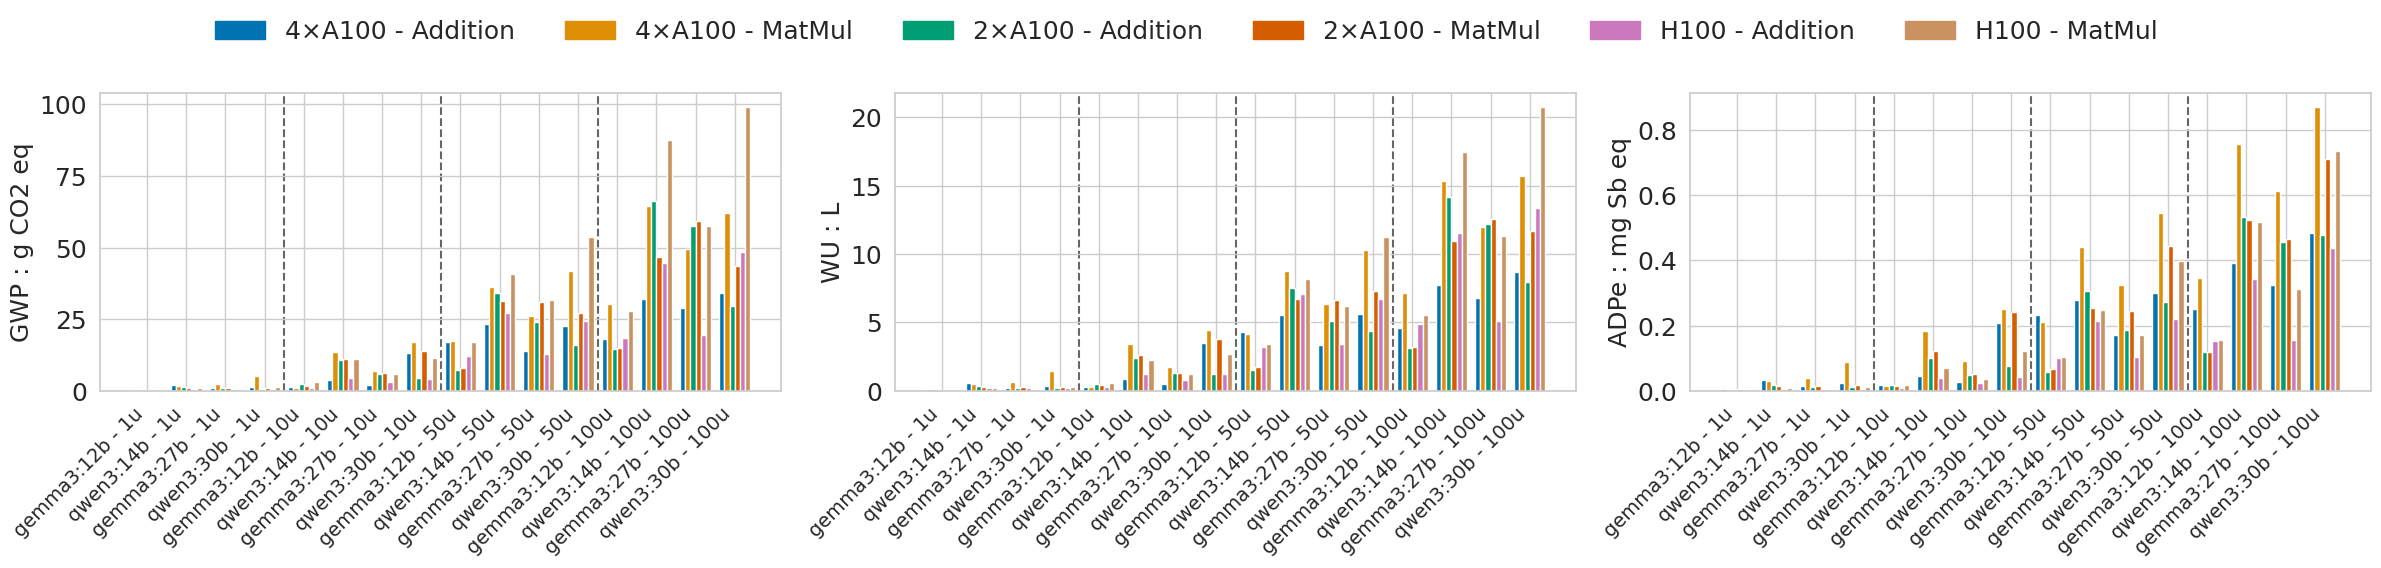

Saved combined impacts across repos: ../outputs


True

In [6]:
df_imp = load_global_impacts_from_repos(DATA_PATH, REPOS)
out_png = OUT_DIR 
out_pdf = OUT_DIR 
plot_impacts_compare_across_repos(df_imp, out_png, out_pdf)

## 1. Latency and Distribution Analysis
Visualizing raw response times and cumulative latency distributions.

In [7]:
def plot_latency_compare_across_repos(df_lat, out_png: Path, out_pdf: Path):
    if df_lat.empty:
        return False
    
    setup_large_fonts() # On suppose que cela définit des tailles élevées
    df = df_lat.copy()
    
    # Prétraitement
    if "nb_users" in df.columns:
        df["nb_users"] = df["nb_users"].astype(str)
    df["repo_disp"] = df["repo"].apply(lambda r: DISPLAY_NAME.get(r, r.replace("Sim_", "")))
    df["response time (s)"] = df["latency"]
    
    # Filtrage et tri des modèles (on en veut exactement 4 pour le 2x2)
    relevant_models = sort_models_by_params([m for m in df["model"].unique() if "gemma3" in str(m).lower() or "qwen3" in str(m).lower()])
    models_to_plot = relevant_models[:4] 
    
    repo_order = [DISPLAY_NAME.get(r, r.replace("Sim_", "")) for r in REPOS]
    users = sorted(df["nb_users"].unique(), key=lambda x: int(x))

    # --- INITIALISATION GRILLE 2x2 COMPACTE ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True, sharex=True)
    axes_flat = axes.flatten()
    
    palette = sns.color_palette("colorblind", len(users))

    for i, model in enumerate(models_to_plot):
        ax = axes_flat[i]
        model_df = df[df["model"] == model]
        
        sns.boxplot(
            data=model_df, x="repo_disp", y="response time (s)", hue="nb_users",
            order=repo_order, hue_order=users, palette=palette, 
            showfliers=False, ax=ax, linewidth=1.5
        )
        
        # Style Interne
        ax.set_yscale("log")
        ax.set_title(model, fontweight='bold', pad=10, fontsize=20)
        ax.get_legend().remove() # On enlève la légende locale
        
        # Nettoyage des axes
        ax.set_xlabel("")
        if i % 2 == 0: ax.set_ylabel("Response time (s)", weight='bold')
        else: ax.set_ylabel("")
        
        # Grille et Ticks
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.grid(True, which="both", ls="-", alpha=0.15)
        ax.tick_params(axis='x', rotation=45)

    # --- LÉGENDE UNIQUE ET COMPACTE (TOUT EN HAUT) ---
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, title="NB Users", 
        loc='upper center', bbox_to_anchor=(0.5, 1.02),
        ncol=len(users), frameon=True, fontsize=16, title_fontsize=18
    )

    # --- AJUSTEMENT DES MARGES (TRÈS SERRÉ) ---
    plt.tight_layout()
    # On laisse un peu de place en haut pour la légende globale
    fig.subplots_adjust(top=0.90, hspace=0.25, wspace=0.1)

    # Sauvegarde
    #out_png.parent.mkdir(parents=True, exist_ok=True)
    #fig.savefig(out_png, dpi=300, bbox_inches="tight")
    #fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
    plt.show()
    #plt.close()
    
    return True

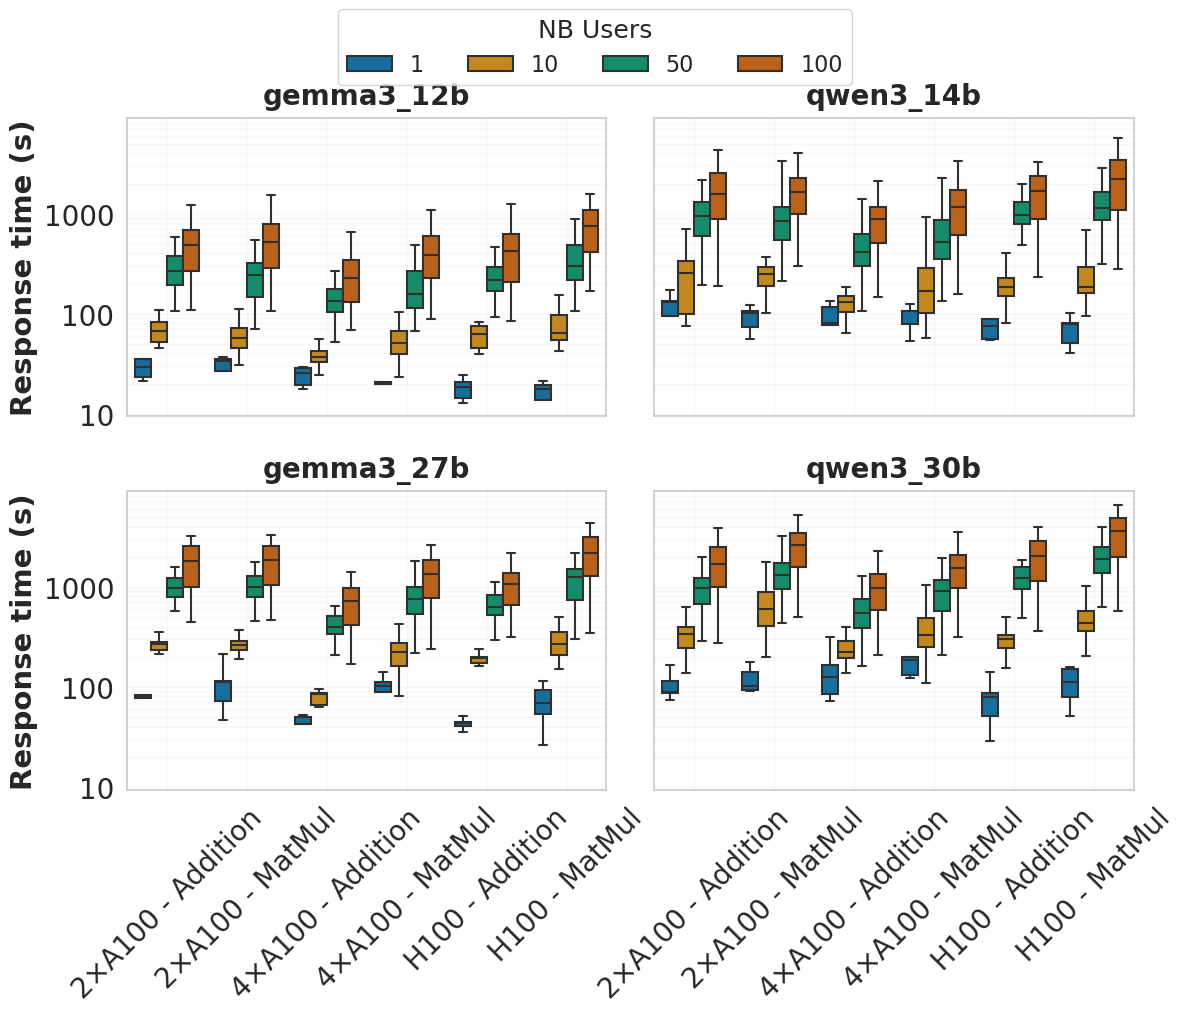

True

In [8]:
df_lat = load_latencies_from_repos(DATA_PATH, REPOS)
# out_png = out_dir_comb / "latency_compare_allrepos.png"
# out_pdf = out_dir_comb / "latency_compare_allrepos.pdf"
plot_latency_compare_across_repos(df_lat, OUT_DIR, OUT_DIR)

## 2. Statistical Impact Boxplots
Comparing Environmental Impacts (GWP, WU, ADPe).

In [9]:
def extract_model_size(model_name):
    """Extrait la taille numérique avant le 'b' à la fin du nom (ex: gemma3:12b -> 12.0)."""
    match = re.search(r'(\d+)b$', str(model_name).lower())
    return float(match.group(1)) if match else 0.0
def get_star_annotation(p_value):
    if p_value < 0.001: return "***"
    if p_value < 0.01: return "**"
    if p_value < 0.05: return "*"
    return ""
def plot_impact_boxplots_publication(df_t, out_base_path):
    # Style Ultra-lisible pour publication
    sns.set_context("paper", font_scale=2.8) # Police très grande
    plt.rcParams.update({
        'axes.labelweight': 'bold',
        'axes.titlesize': 32, # Titres GWP, WU, ADP massifs
        'axes.labelsize': 24,
        'xtick.labelsize': 20,
        'ytick.labelsize': 20,
        'savefig.bbox': 'tight'
    })

    metrics_order = ["GWP", "WU", "ADPe"]
    plot_df = df_t.copy()
    
    for m in metrics_order:
        if m in plot_df.columns:
            plot_df[m] = pd.to_numeric(plot_df[m], errors='coerce') * SCALE_MAP.get(m, 1.0)

    # Nettoyage et tri des modèles par taille extraite
    plot_df['Model_Name'] = plot_df.index.str.replace(r'\.\d+$', '', regex=True)
    plot_df['Model_Size'] = plot_df['Model_Name'].apply(extract_model_size)
    model_order = plot_df[['Model_Name', 'Model_Size']].drop_duplicates().sort_values('Model_Size')['Model_Name'].tolist()

    # Figure plus compacte (plus étroite)
    fig, axes = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)
    
    row_configs = [
        ('Infrastructure', None, 'Set2'),
        ('Problem', None, 'Set3'),
        ('Model_Name', model_order, 'viridis')
    ]

    for row_idx, (col_name, order, palette) in enumerate(row_configs):
        groups = order if order else sorted(plot_df[col_name].unique())
        
        for col_idx, metric in enumerate(metrics_order):
            ax = axes[row_idx, col_idx]
            
            sns.boxplot(ax=ax, data=plot_df, x=col_name, y=metric, order=order, 
                        palette=palette,hue=col_name, showfliers=False, width=0.7)
            sns.stripplot(ax=ax, data=plot_df, x=col_name, y=metric, order=order, 
                          color='black', alpha=0.4, jitter=True, size=6)
            
            # --- Test Statistique Inférentiel ---
            data_per_group = [plot_df[plot_df[col_name] == g][metric].dropna().values for g in groups]
            data_per_group = [d for d in data_per_group if len(d) > 1]
            
            if len(data_per_group) > 1:
                _, p_anova = stats.f_oneway(*data_per_group)
                if p_anova < 0.05:
                    means = [np.mean(d) for d in data_per_group]
                    ref_idx = np.argmin(means)
                    ref_data = data_per_group[ref_idx]
                    y_range = plot_df[metric].max() - plot_df[metric].min()
                    
                    for i, (g, data) in enumerate(zip(groups, [plot_df[plot_df[col_name] == g][metric].dropna().values for g in groups])):
                        if i == ref_idx or len(data) < 2: continue
                        _, p_val = stats.ttest_ind(ref_data, data, equal_var=False)
                        p_corr = min(1.0, p_val * (len(data_per_group) - 1)) # Bonferroni
                        stars = get_star_annotation(p_corr)
                        if stars:
                            ax.text(i, data.max() + 0.03 * y_range, stars, ha='center', 
                                    color='red', fontweight='bold', fontsize=28) # Étoiles plus grandes

            # Titres de colonnes massifs (uniquement ligne 1)
            if row_idx == 0:
                ax.set_title(metric, fontweight='bold', pad=15)
            
            ax.set_ylabel(UNIT_LABELS.get(metric, ""), fontsize=22)
            ax.set_xlabel("") # Compact : on retire le nom de l'axe X
            
            # Labels X : rotation pour la ligne des modèles
            if row_idx == 2:
                plt.setp(ax.get_xticklabels(), rotation=35, ha='right')

    # Export PDF et PNG haute résolution
    #output_dir = Path(out_base_path).parent
    #output_dir.mkdir(parents=True, exist_ok=True)

    #fig.savefig(out_base_path + ".png", dpi=300)
    #fig.savefig(out_base_path + ".pdf", format='pdf')
    #plt.close()
    plt.show()
    return True

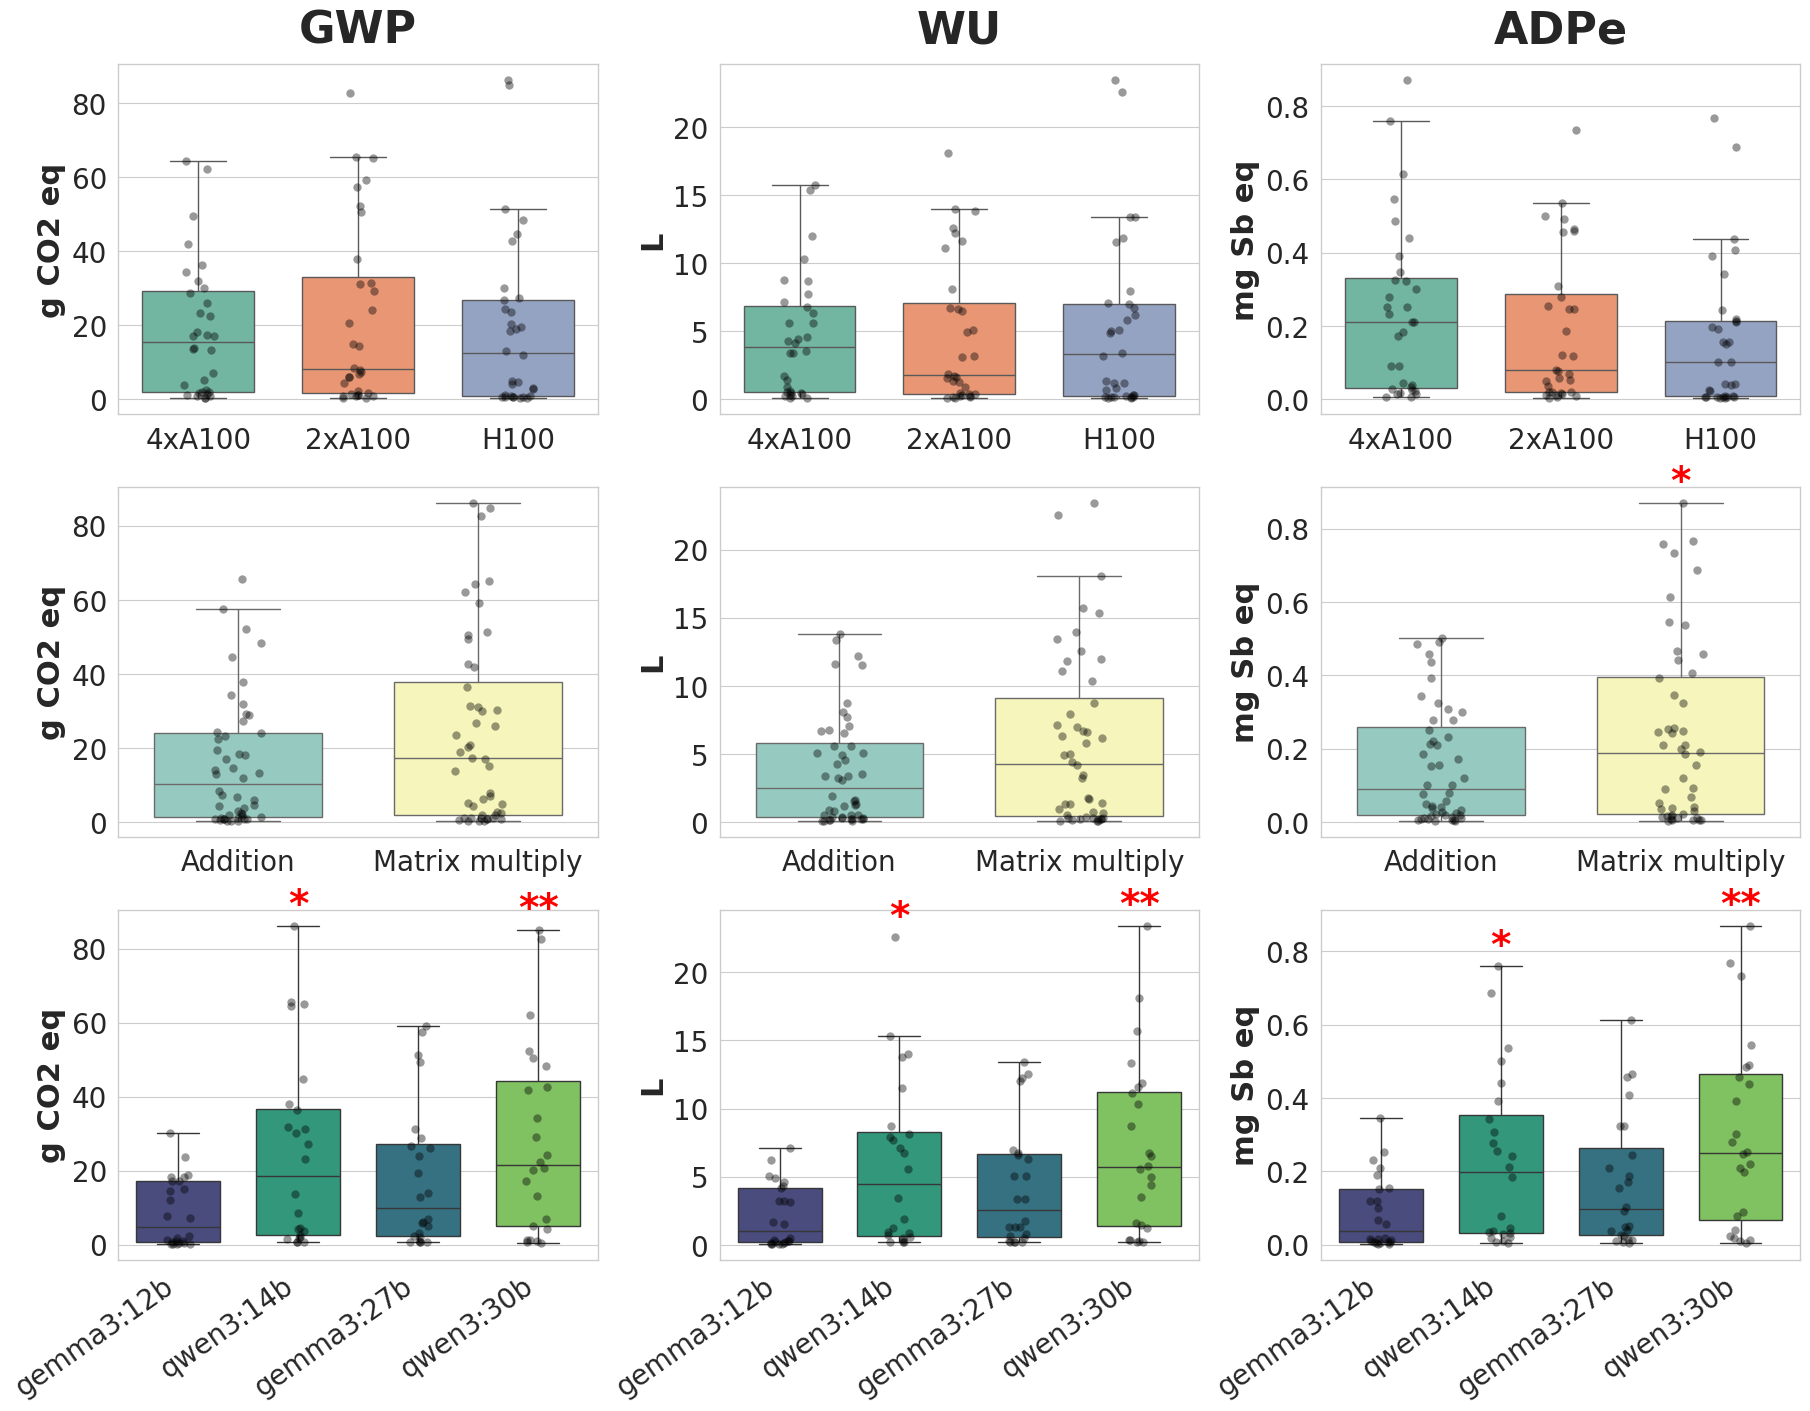

In [10]:
out_csv = Path("../outputs/compare_models_combined.csv")
img_base = "../outputs/images/impact_compact_analysis"
if out_csv.exists():
        df_t = pd.read_csv(out_csv, index_col=0).T
        df_t["ADPe"] = df_t["ADP"].fillna(0)
        for col in ["GWP", "ADPe", "WU"]:
            if col in df_t.columns:
                df_t[col] = pd.to_numeric(df_t[col], errors='coerce')

        plot_impact_boxplots_publication(df_t, img_base)

## 3. QoS and Impact Efficiency
Environmental cost per unit of Quality of Use.

In [11]:
def sort_models_by_size(model_list):
    def extract_params(m):
        match = re.search(r'(\d+)b', str(m).lower())
        return int(match.group(1)) if match else 0
    return sorted(list(set(model_list)), key=extract_params)

TARGET_MODELS = sort_models_by_size(df_sr['Model'].unique())
sr_map = {
    "Addition": df_sr.set_index('Model')['Average Addition (%)'].to_dict(),
    "MatMul": df_sr.set_index('Model')['Average MatMul (%)'].to_dict()
}

def load_all_data(root: Path):
    lat_rows, imp_rows = [], []
    
    print(f"--- DIAGNOSTIC ---")
    print(f"TARGET_MODELS attendus : {TARGET_MODELS}")

    for repo in REPOS:
        infra = "2×A100" if "Grouille" in repo else ("4×A100" if "Chuc" in repo else "H100")
        task = "MatMul" if "matrix" in repo.lower() else "Addition"
        
        d_path = root / repo / "measure" / "data"
        if not d_path.exists():
            continue
        
        # On liste TOUS les fichiers csv de latence sans exception
        files = list(d_path.glob("raw_latencies_*.csv"))
        
        for p in files:
            # Extraction brute du nom du modèle
            model_file_raw = p.name.replace("raw_latencies_", "").replace(".csv", "")
            
            # --- ACTION : On enlève le filtre 'if model in TARGET_MODELS' pour tester ---
            # Cela permet de voir si les fichiers sont bien lus.
            try:
                df = pd.read_csv(p)
                if df.empty:
                    print(f"Fichier vide ignoré : {p.name}")
                    continue
                
                # Détection de colonnes flexible
                nb_c = next((c for c in ["nb_users", "nb_user"] if c in df.columns), None)
                
                # On cherche une colonne numérique pour la latence
                numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
                # On exclut nb_user de la recherche de la colonne latence
                candidates = [c for c in numeric_cols if c != nb_c]
                lat_c = "latency" if "latency" in df.columns else (candidates[0] if candidates else None)
                
                if lat_c is None:
                    print(f"Pas de colonne de latence trouvée dans {p.name}")
                    continue

                for _, r in df.iterrows():
                    lat_rows.append({
                        "infra": infra, 
                        "task": task, 
                        "model": model_file_raw, # On prend le nom brut du fichier
                        "nb_users": int(r[nb_c]) if nb_c else 1, 
                        "latency": float(r[lat_c])
                    })
                    
            except Exception as e:
                print(f"Erreur lors de la lecture de {p.name} : {e}")
        imp_p = d_path / "global_impacts_mtc.csv"
        if imp_p.exists():
            df = pd.read_csv(imp_p)
            df['model'] = df['model'].astype(str).str.replace('-', ':')
            for _, r in df.iterrows():
                imp_rows.append({"infra": infra, "task": task, "model": r["model"], "nb_users": int(r.get("nb_user", 1)), "factor": r.get("factor", ""), "value": float(r.get("total", 0.0))})
            
            

    df_lat = pd.DataFrame(lat_rows)
    
    # --- POST-FILTRAGE ---
    if not df_lat.empty:
        print(f"Modèles réellement trouvés dans les fichiers : {df_lat['model'].unique().tolist()}")
        # On ne garde que ce qui nous intéresse si nécessaire
        # df_lat = df_lat[df_lat['model'].isin(TARGET_MODELS)]
    else:
        print("ALERTE : Toujours aucune donnée chargée. Vérifiez les chemins 'd_path'.")
        print(f"Dernier chemin testé : {d_path}")
        

    return df_lat, pd.DataFrame(imp_rows)

# Teste la fonction
df_lat, df_imp = load_all_data(DATA_PATH)
print(df_lat.head())
def sort_models_by_size(model_list):
    def extract_params(m):
        match = re.search(r'(\d+)b', str(m).lower())
        return int(match.group(1)) if match else 0
    return sorted(list(set(model_list)), key=extract_params)

TARGET_MODELS = sort_models_by_size(df_sr['Model'].unique())
sr_map = {
    "Addition": df_sr.set_index('Model')['Average Addition (%)'].to_dict(),
    "MatMul": df_sr.set_index('Model')['Average MatMul (%)'].to_dict()
}
def f_score_idx(value, factor, base_dict):
    v_scaled = value * SCALE_MAP.get(factor, 1.0)
    base = base_dict.get(factor, 1e-9)
    return 10.0 if v_scaled <= base else 10.0 * (base/v_scaled)

def setup_radar_ax(ax, angles, categories):
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    # Correction superposition : Augmentation du padding (pad=25) pour éloigner le texte
    for label, angle in zip(ax.get_xticklabels(), angles):
        # On met à la verticale (90°)
        label.set_rotation(90)
        # Optionnel : Ajuster l'alignement pour que ce soit centré
        label.set_verticalalignment('center')
        label.set_horizontalalignment('center')
    ax.set_xticklabels(categories, weight='bold', fontsize=12)
    ax.tick_params(axis='x', pad=10) 
    ax.set_yticks([2, 4, 6, 8, 10])
    ax.set_yticklabels(["2", "4", "6", "8", "10"], color="grey", size=9)
    ax.set_ylim(0, 10.5)


--- DIAGNOSTIC ---
TARGET_MODELS attendus : ['gemma3:12b', 'qwen3:14b', 'gemma3:27b', 'qwen3:30b']
Modèles réellement trouvés dans les fichiers : ['gemma3_27b', 'gpt-oss_20b', 'gemma3_12b', 'qwen3_30b', 'qwen3_14b']
    infra      task       model  nb_users     latency
0  2×A100  Addition  gemma3_27b         1   81.722207
1  2×A100  Addition  gemma3_27b         1   81.765490
2  2×A100  Addition  gemma3_27b         1   49.008852
3  2×A100  Addition  gemma3_27b         1   78.060677
4  2×A100  Addition  gemma3_27b         1  119.916626


--- DIAGNOSTIC ---
TARGET_MODELS attendus : ['gemma3:12b', 'qwen3:14b', 'gemma3:27b', 'qwen3:30b']
Modèles réellement trouvés dans les fichiers : ['gemma3_27b', 'gpt-oss_20b', 'gemma3_12b', 'qwen3_30b', 'qwen3_14b']
      infra      task       model  nb_users factor         value
0    2×A100  Addition  gemma3:12b         1    GWP  1.807385e-04
1    2×A100  Addition  gemma3:12b         1   ADPe  2.029744e-09
2    2×A100  Addition  gemma3:12b         1     WU  4.240752e-05
3    2×A100  Addition  gemma3:12b        10    GWP  1.186657e-03
4    2×A100  Addition  gemma3:12b        10   ADPe  9.448652e-09
..      ...       ...         ...       ...    ...           ...
991    H100    MatMul   qwen3:14b       100     WU  1.744444e-02
992    H100    MatMul   qwen3:30b         1     WU  2.742666e-04
993    H100    MatMul   qwen3:30b        10     WU  2.662880e-03
994    H100    MatMul   qwen3:30b        50     WU  1.123547e-02
995    H100    MatMul   qwen3:30b       100     WU  2.073154e-02

[99

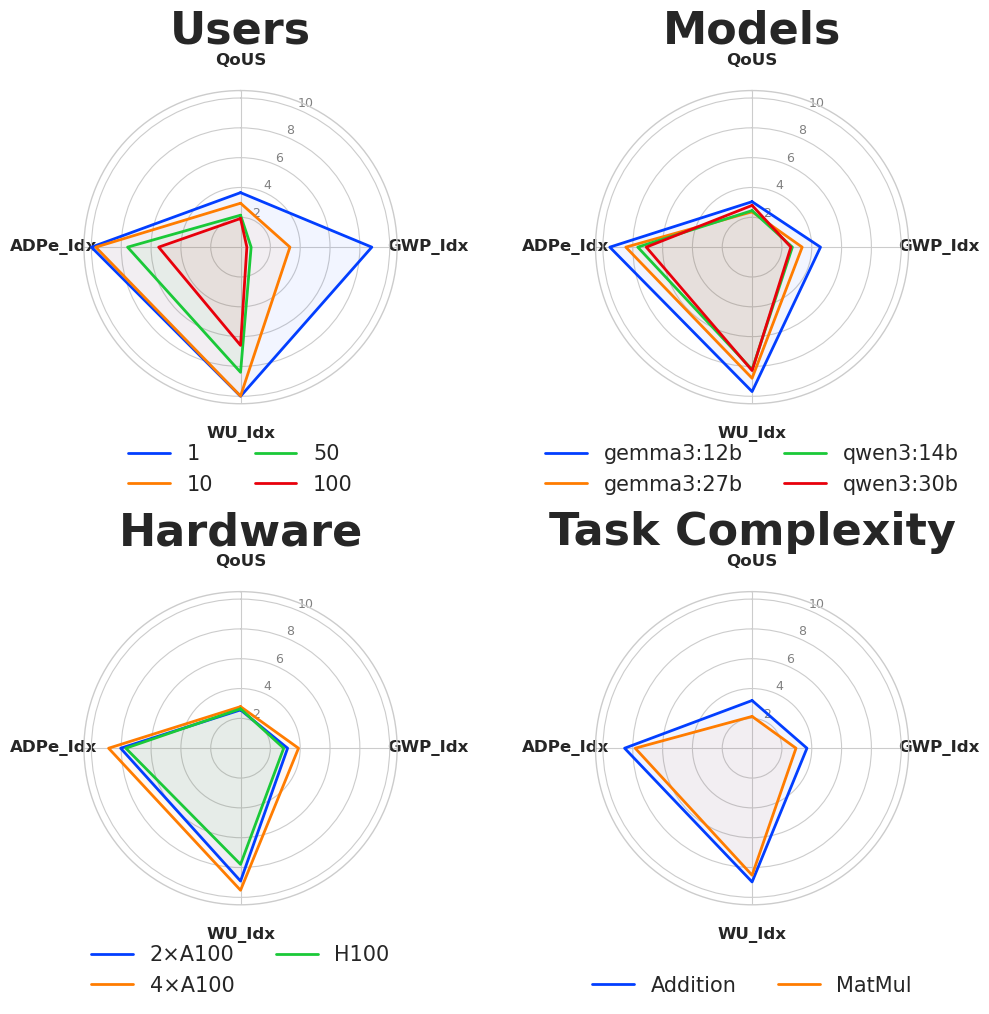

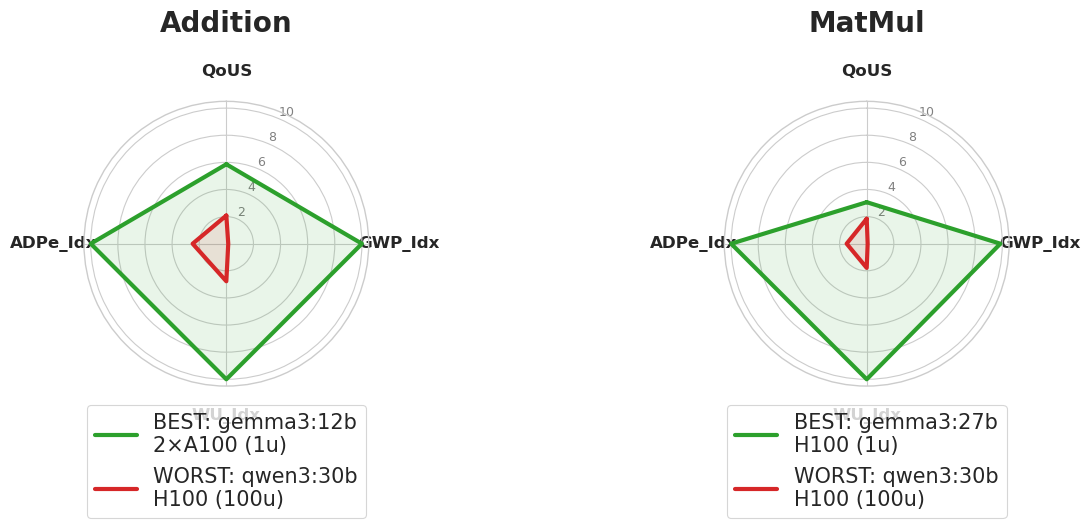

In [12]:
df_lat, df_imp = load_all_data(DATA_PATH)
print(df_imp)
df_lat['model'] = df_lat['model'].str.replace('_', ':')
df_lat = df_lat[df_lat['model'] != 'gpt-oss:20b']
df_lat['qos'] = df_lat.apply(
    lambda r: (sr_map[r['task']][r['model']]/100.0) * (10.0 if r['latency'] <= 60 else 10.0/(1.0 + np.log10(r['latency']/60.0))), 
    axis=1
)
avg_qos = df_lat.groupby(['infra', 'model', 'nb_users', 'task'], observed=True)['qos'].mean().reset_index()
df_s = pd.read_csv(io.StringIO(STREAMING_DATA))
base_dict = {r['factor']: (r['value/hour']/60.0) * SCALE_MAP[r['factor']] for _, r in df_s.iterrows()}

merged = pd.merge(avg_qos, df_imp, on=['infra', 'model', 'nb_users', 'task'])
merged['idx'] = merged.apply(lambda r: f_score_idx(r['value'], r['factor'], base_dict), axis=1)

radar_piv = merged.pivot_table(index=['infra', 'model', 'nb_users', 'task'], columns='factor', values='idx').reset_index()
final = pd.merge(avg_qos, radar_piv, on=['infra', 'model', 'nb_users', 'task']).rename(
    columns={'GWP': 'GWP_Idx', 'WU': 'WU_Idx', 'ADPe': 'ADPe_Idx', 'qos': 'QoUS'})

categories = ['QoUS', 'GWP_Idx', 'WU_Idx', 'ADPe_Idx']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# --- FICHIER 1 : ANALYSES (4 RADARS) ---
grouping_vars = {"nb_users": "Users", "model": "Models", "infra": "Hardware", "task": "Task Complexity"}
fig1, axes1 = plt.subplots(2, 2, figsize=(11, 11), subplot_kw=dict(polar=True))
for ax, (var, label) in zip(axes1.flatten(), grouping_vars.items()):
    palette = sns.color_palette("bright", len(final[var].unique()))
    for i, (name, row) in enumerate(final.groupby(var)):
        values = [row[c].mean() for c in categories]
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=str(name), color=palette[i])
        ax.fill(angles, values, color=palette[i], alpha=0.05)
    setup_radar_ax(ax, angles, categories)
    ax.set_title(label, pad=5, weight='bold') # Augmentation du pad titre
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False, fontsize=15)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6, wspace=0.4)
#fig1.savefig(out / "720p_main_analysis.pdf", bbox_inches='tight')
plt.show()
# --- FICHIER 2 : EXTREMES (2 RADARS SUR LA MÊME LIGNE) ---
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 7), subplot_kw=dict(polar=True))
final['total_score'] = final[categories].mean(axis=1)

for ax, task in zip(axes2, ["Addition", "MatMul"]):
    task_df = final[final['task'] == task]
    if task_df.empty: continue
    best = task_df.loc[task_df['total_score'].idxmax()]
    worst = task_df.loc[task_df['total_score'].idxmin()]
    
    for entry, color, l_type in [(best, '#2ca02c', 'BEST'), (worst, '#d62728', 'WORST')]:
        values = [entry[c] for c in categories]
        values += values[:1]
        label_text = f"{l_type}: {entry['model']}\n{entry['infra']} ({entry['nb_users']}u)"
        ax.plot(angles, values, linewidth=3, label=label_text, color=color)
        ax.fill(angles, values, color=color, alpha=0.1)

    setup_radar_ax(ax, angles, categories)
    ax.set_title(task, pad=50, weight='bold', fontsize=20)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), frameon=True, fontsize=15)

plt.tight_layout()
plt.subplots_adjust(wspace=0.01)
plt.show()
#fig2.savefig(out / "720p_extremes.pdf", bbox_inches='tight')


In [13]:
# --- CONFIGURATION ---
pedigree_matrix = {
    "reliability":       [1.00, 1.54, 1.61, 1.69, 1000.0],
    "completeness":     [1.00, 1.03, 1.04, 1.08, 1000.0],
    "temporal":         [1.00, 1.03, 1.10, 1.19, 1.29],
    "geographical":     [1.00, 1.04, 1.08, 1.11, 1000.0],
    "technological":    [1.00, 1.18, 1.65, 2.08, 2.80]
}

scores_ADP_GWP = {"reliability": 2, "completeness": 2, "temporal": 5, "geographical": 1, "technological": 1}
scores_WU      = {"reliability": 2, "completeness": 2, "temporal": 3, "geographical": 2, "technological": 2}
scores_F       = {"reliability": 3, "completeness": 2, "temporal": 1, "geographical": 1, "technological": 4}

def compute_gsd_and_ln_sq(scores, matrix):
    ln_sq_sum = 0.0
    for key, score in scores.items():
        I = matrix[key][score-1]
        ln_sq_sum += np.log(I) ** 2
    return math.exp(math.sqrt(ln_sq_sum)), ln_sq_sum

print(f"Compute GSD carré for ADP_GWP: {compute_gsd_and_ln_sq(scores_ADP_GWP, pedigree_matrix)[0]}")
print(f"Compute GSD carré for WU: {compute_gsd_and_ln_sq(scores_WU, pedigree_matrix)[0]}")
print(f"Compute GSD carré for F: {compute_gsd_and_ln_sq(scores_F, pedigree_matrix)[0]}")

def find_global_csvs():
    script_dir = DATA_PATH
    workspace_root = os.path.abspath(os.path.join(script_dir, os.pardir))
    found_files = []
    for repo in REPOS:
        p = os.path.join(DATA_PATH, repo, "measure", "data", "global_impacts_mtc.csv")
        if os.path.exists(p):
            found_files.append((repo, p))
    return found_files

def load_global_data(file_tuples):
    dfs = []
    for repo_name, p in file_tuples:
        try:
            df = pd.read_csv(p)
            df['repo'] = repo_name
            dfs.append(df)
        except Exception as e:
            print(f"Warning: failed to read {p}: {e}")
    if not dfs: return pd.DataFrame()
    all_df = pd.concat(dfs, ignore_index=True)
    return all_df.loc[all_df["scope"].str.lower() == "global"].copy()

def propagate_uncertainty(df):
    rows = []
    for _, r in df.iterrows():
        repo, model, factor, total = r["repo"], r["model"], r["factor"], float(r["total"])
        usage = float(r.get("usage", 0.0))
        manuf = float(r.get("manufacturing", 0.0))

        u_scores = scores_WU if factor.lower() == "wu" else scores_ADP_GWP
        gsd_u, ln_sq_u = compute_gsd_and_ln_sq(u_scores, pedigree_matrix)
        gsd_m, ln_sq_m = compute_gsd_and_ln_sq(scores_F, pedigree_matrix)

        s_u = usage / total if total > 0 else 0
        s_m = manuf / total if total > 0 else 0
        ln_gsd_total_sq = (s_u**2 * ln_sq_u) + (s_m**2 * ln_sq_m)
        gsd_total = math.exp(math.sqrt(ln_gsd_total_sq))

        rows.append({
            "repo": repo, "model": model, "nb_user": r["nb_user"], "factor": factor,
            "total": total, "gsd_total": gsd_total,
            "lower": total / gsd_total**2 if gsd_total > 0 else total,
            "upper": total * gsd_total**2
        })
    return pd.DataFrame(rows)

def plot_intervals_by_factor(res_df, out_png="global_uncertainty_by_factor.png",out_pdf="global_uncertainty_by_factor.pdf"):
    os.makedirs("CI_analysis/outputs", exist_ok=True)
    factors = res_df["factor"].unique()
    n_factors = len(factors)
    
    # Création d'une figure avec un sous-graphique par facteur
    fig, axes = plt.subplots(n_factors, 1, figsize=(14, 6 * n_factors), squeeze=False)
    
    repos = res_df["repo"].unique()
    models = res_df["model"].unique()
    
    # Mapping Styles
    colors = plt.cm.get_cmap("tab10", len(repos))
    repo_color_map = {repo: colors(i) for i, repo in enumerate(repos)}
    all_markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'h']
    model_marker_map = {model: all_markers[i % len(all_markers)] for i, model in enumerate(models)}

    for idx, factor in enumerate(factors):
        ax = axes[idx, 0]
        f_df = res_df[res_df["factor"] == factor].sort_values(["repo", "model"])
        x_pos = np.arange(len(f_df))
        
        for i, (_, row) in enumerate(f_df.iterrows()):
            y = row["total"]
            yerr = [[y - row["lower"]], [row["upper"] - y]]
            ax.errorbar(i, y, yerr=yerr, fmt=model_marker_map[row["model"]], 
                        color=repo_color_map[row["repo"]], ecolor='gray', 
                        capsize=4, markersize=9, alpha=0.8)

        ax.set_yscale('log')
        ax.set_xticks([])        # Supprime les positions des ticks
        ax.set_xticklabels([])   # Supprime les textes
        ax.set_title(f"Impact Factor: {factor.upper()}", fontsize=14, fontweight='bold', pad=20)
        ax.set_ylabel("Impact Value (log)")
        ax.grid(True, which="both", ls="--", alpha=0.3)

    # Légende globale unique
    legend_elements = [Line2D([0], [0], color='black', lw=0, label='--- REPOS ---')]
    for r, c in repo_color_map.items():
        legend_elements.append(Line2D([0], [0], marker='s', color='w', label=r, markerfacecolor=c, markersize=10))
    legend_elements.append(Line2D([0], [0], color='w', label=' '))
    legend_elements.append(Line2D([0], [0], color='black', lw=0, label='--- MODELS ---'))
    for m, mark in model_marker_map.items():
        legend_elements.append(Line2D([0], [0], marker=mark, color='w', label=m, markerfacecolor='gray', markersize=10))

    fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)
    plt.tight_layout()
    plt.show()
    #save_path = os.path.join("CI_analysis/outputs", out_png)
    #save_path_pdf = os.path.join("CI_analysis/outputs", out_pdf)
    #plt.savefig(save_path, dpi=300, bbox_inches='tight')
    #plt.savefig(save_path_pdf, dpi=300, bbox_inches='tight')
    #print(f"Graphique par facteur sauvegardé : {save_path}")


Compute GSD carré for ADP_GWP: 1.6522662396905325
Compute GSD carré for WU: 1.6075098739971976
Compute GSD carré for F: 2.396696216404039


[('Sim_Grouille', '../../experiments_data/Sim_Grouille/measure/data/global_impacts_mtc.csv'), ('Sim_Grouille_matrix', '../../experiments_data/Sim_Grouille_matrix/measure/data/global_impacts_mtc.csv'), ('Sim_Chuc', '../../experiments_data/Sim_Chuc/measure/data/global_impacts_mtc.csv'), ('Sim_Chuc_matrix', '../../experiments_data/Sim_Chuc_matrix/measure/data/global_impacts_mtc.csv'), ('Sim_Hydra', '../../experiments_data/Sim_Hydra/measure/data/global_impacts_mtc.csv'), ('Sim_Hydra_matrix', '../../experiments_data/Sim_Hydra_matrix/measure/data/global_impacts_mtc.csv')]
        gpu       model  nb_user factor   scope     total     usage  \
96   GLOBAL  gemma3:12b        1    GWP  global  0.000252  0.000173   
97   GLOBAL  gemma3:12b       10    GWP  global  0.002345  0.001987   
98   GLOBAL  gemma3:12b       50    GWP  global  0.007289  0.006202   
99   GLOBAL  gemma3:12b      100    GWP  global  0.014494  0.012236   
100  GLOBAL  gemma3:27b        1    GWP  global  0.000857  0.000635   
.

/tmp/nix-shell-3639-2466019931/ipykernel_19092/2650575426.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(repos))


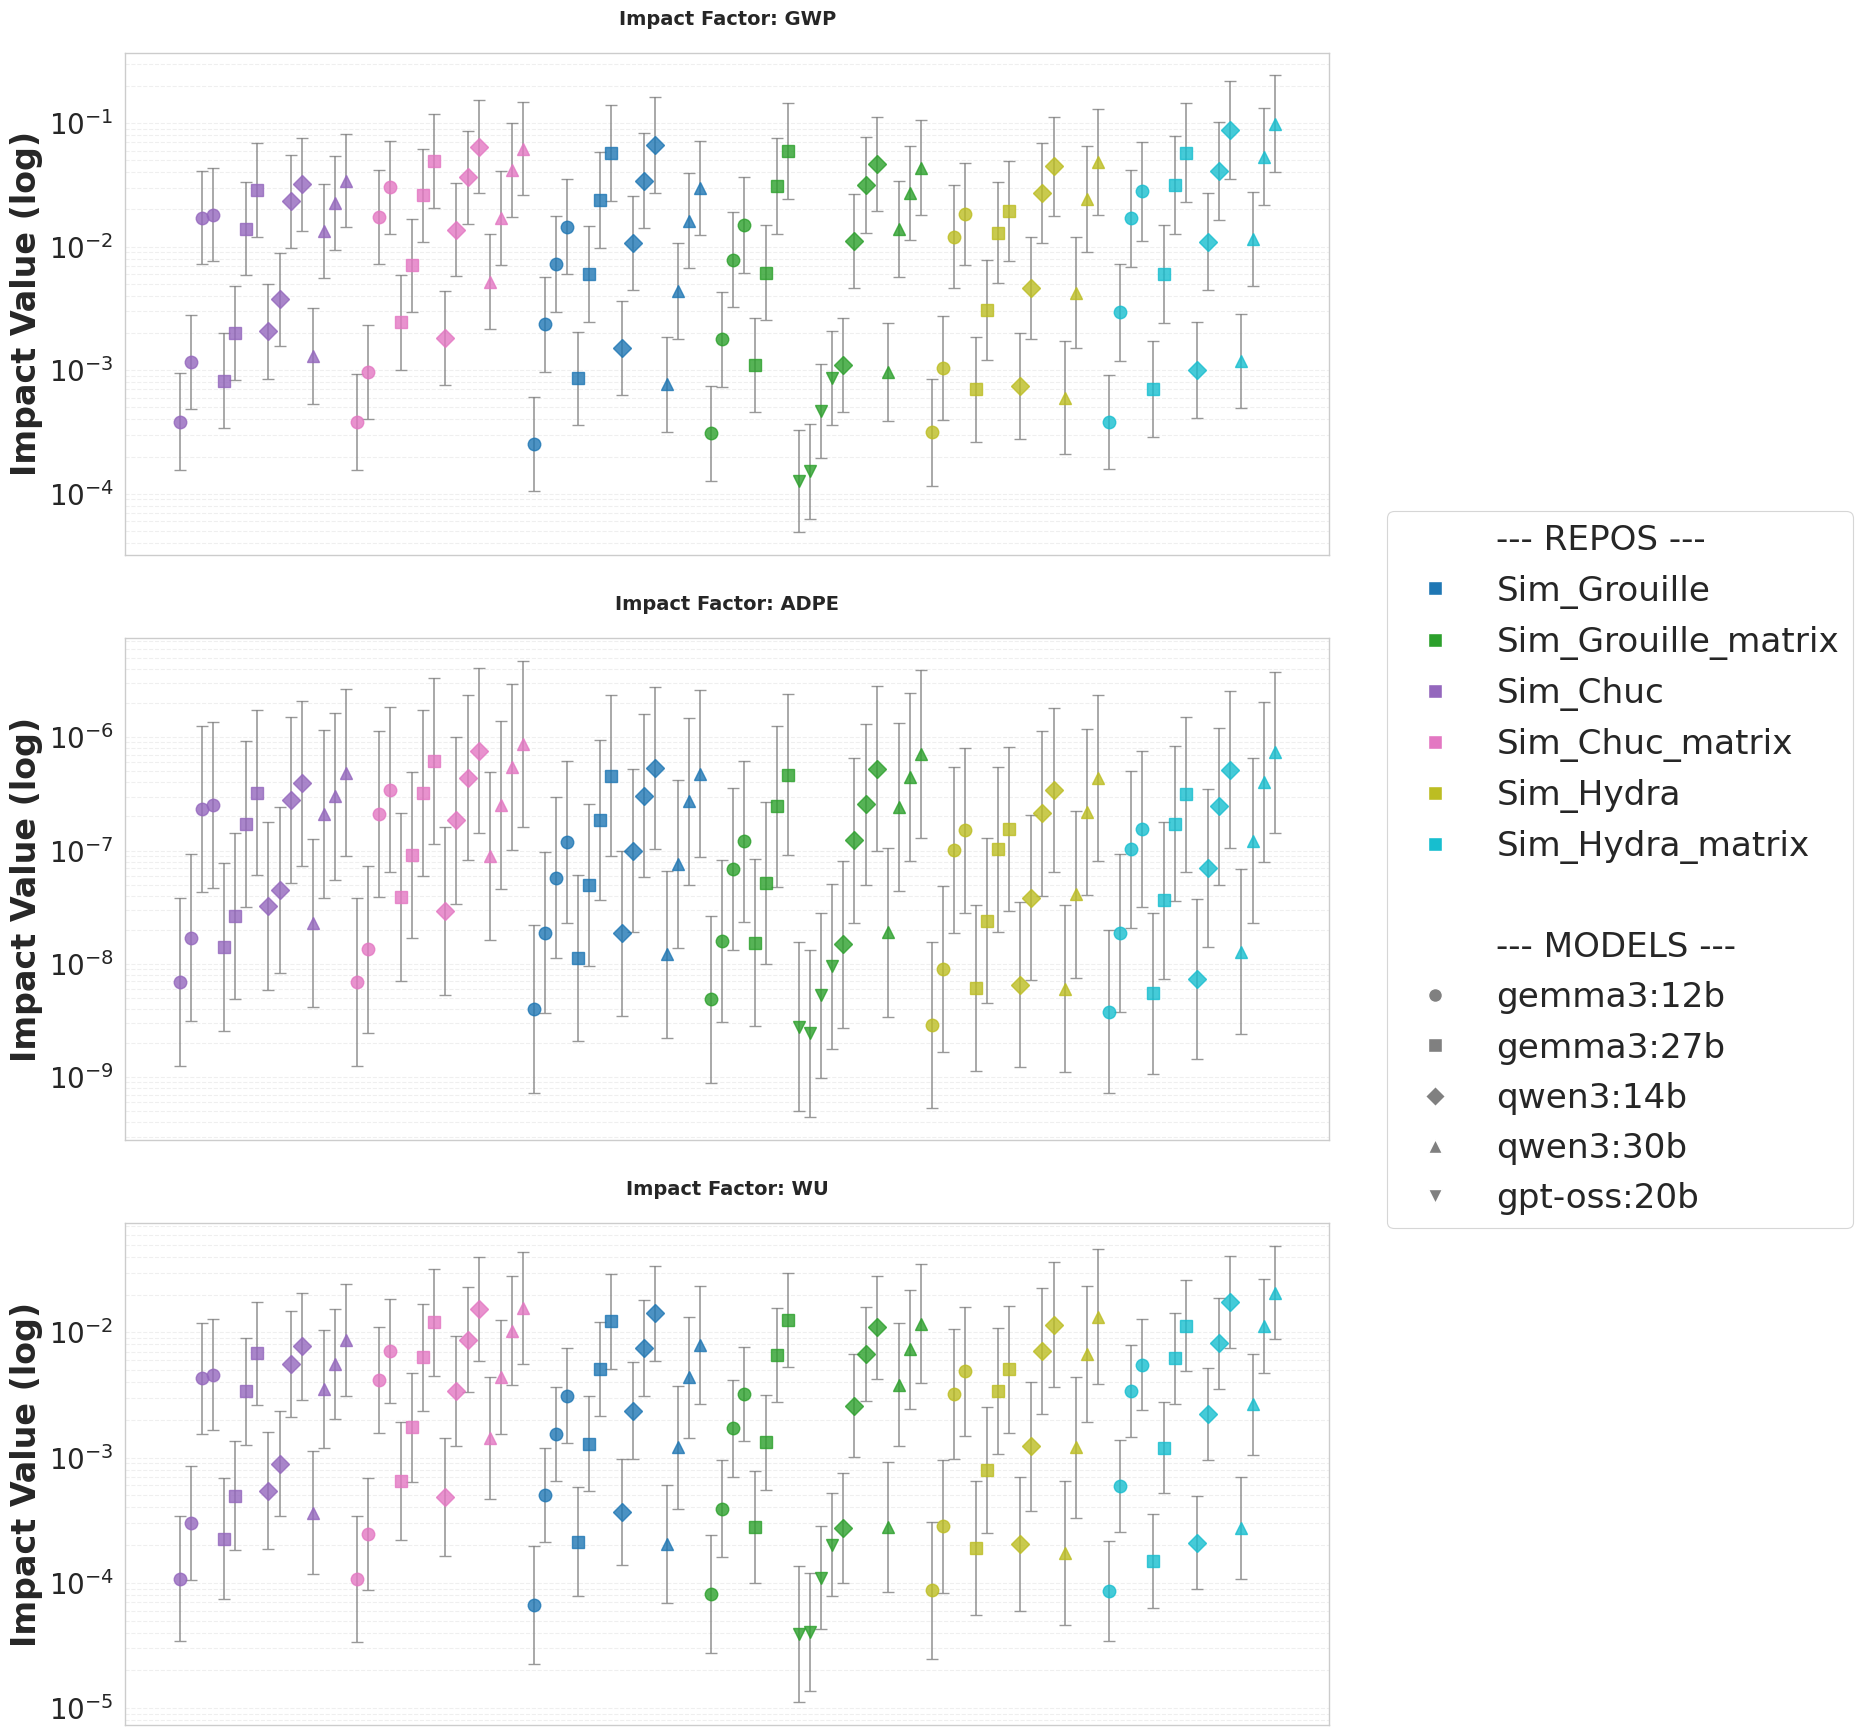

In [14]:
csv_info = find_global_csvs()
print(csv_info)
    
gdf = load_global_data(csv_info)
print(gdf)
res = propagate_uncertainty(gdf)
print(res)
# Sauvegarde du CSV final avec la colonne factor
#os.makedirs("CI_analysis/outputs", exist_ok=True)
#res.to_csv("CI_analysis/outputs/global_uncertainty_intervals.csv", index=False)
    
plot_intervals_by_factor(res)